/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_9439/2096424271.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)
/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_9439/2096424271.py:161: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Comic Sans MS.
  plt.tight_layout(rect=[0,0,1,0.95])
/Users/emilschmiedl/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Comic Sans MS.
  fig.canvas.print_figure(bytes_io, **kw)


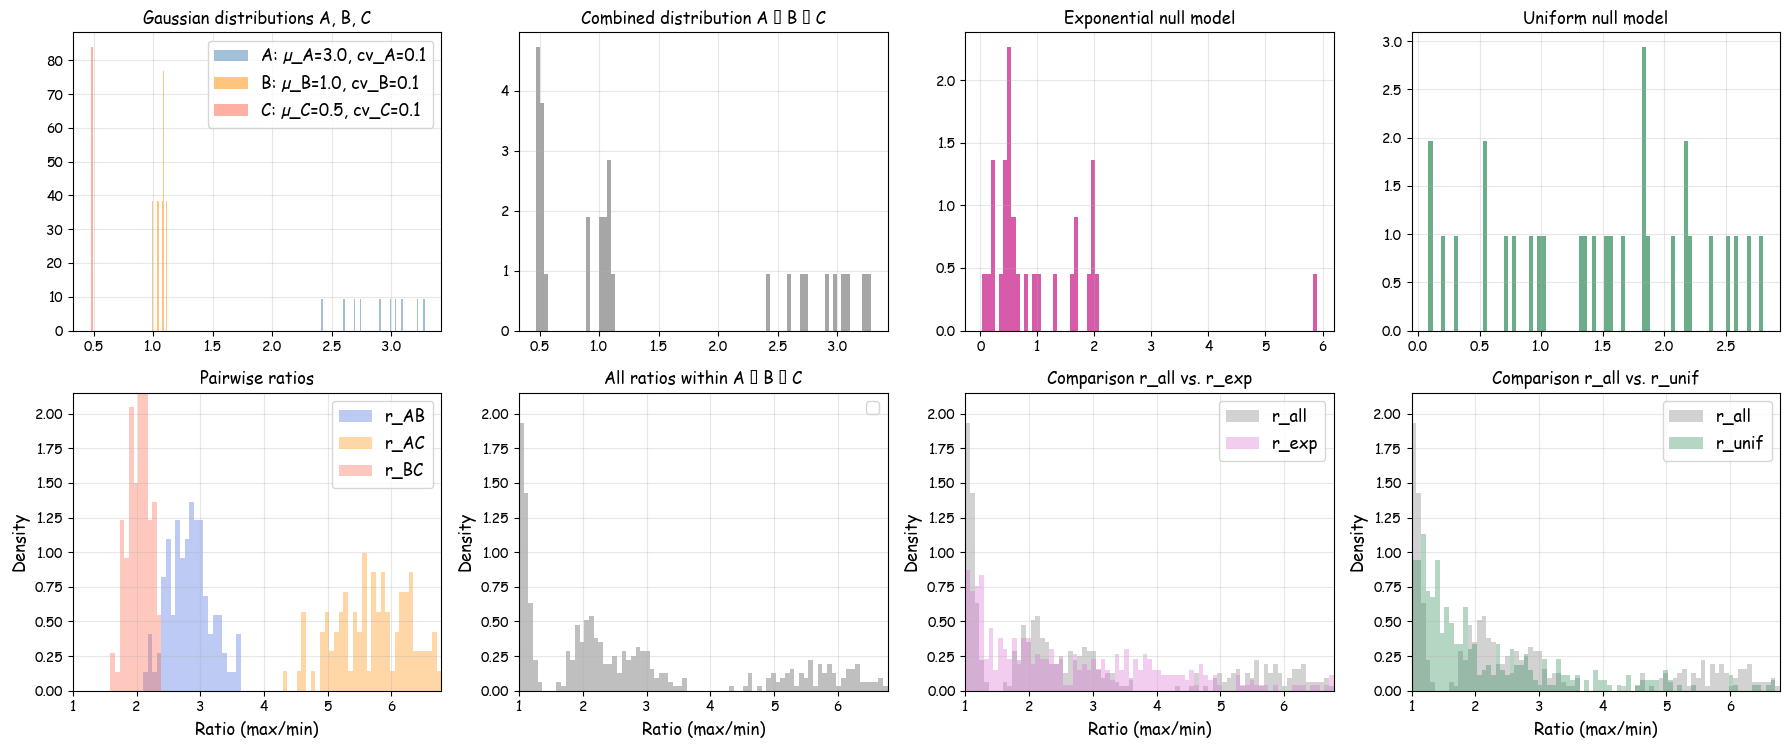

In [ ]:
# old introduction
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_ratio_panel_abc(
    sample_size=600,
    means=(30.2, 20.0, 10.0),
    cvs=(0.1, 0.13, 0.15),
    bins=80,
    random_seed=42,
    show_kde=True
):
    rng = np.random.default_rng(random_seed)

    # --- Three Gaussians ---
    stds = [m*c for m,c in zip(means, cvs)]
    A = rng.normal(means[0], stds[0], sample_size)
    B = rng.normal(means[1], stds[1], sample_size)
    C = rng.normal(means[2], stds[2], sample_size)

    all_values = np.concatenate([A, B, C])

    # Ratio-Function
    def ratio_pairs_unique(x, y):
        """Calculate ratios for unique pairs (x_i, y_j) with i<j, or all combinations if x and y differ."""
        x = np.asarray(x)
        y = np.asarray(y)
        if np.array_equal(x, y):
            # same list → only unique pairs
            i_idx, j_idx = np.triu_indices(len(x), k=1)
            r = x[i_idx] / y[j_idx]
        else:
            # different lists → all combinations
            r = x[:, None] / y[None, :]
            r = r.ravel()
        r = np.maximum(r, 1 / r)
        return r

    # --- Exponential Null Model ---
    mean_all = all_values.mean()
    E = rng.exponential(scale=mean_all, size=len(all_values))

    # --- Uniform Null Model ---
    #min_all = all_values.min()
    min_all = 0.01
    max_all = all_values.max()
    U = rng.uniform(low=min_all, high=max_all, size=len(all_values))

    # --- Ratios ---
    r_AB = ratio_pairs_unique(A, B)
    r_AC = ratio_pairs_unique(A, C)
    r_BC = ratio_pairs_unique(B, C)
    r_all = ratio_pairs_unique(all_values, all_values)
    r_exp = ratio_pairs_unique(E, E)
    r_unif = ratio_pairs_unique(U, U)

    # X-axis limits for ratio plots
    x_min = 1
    x_max = np.percentile(np.concatenate([r_AB, r_AC, r_BC, r_all]), 99)
    bins_lin = np.linspace(x_min, x_max, bins)

    fig, axs = plt.subplots(2, 4, figsize=(18,8))

    # --- Top row ---
    # 1a: Separate Gaussians
    axs[0,0].hist(A, bins=bins, density=True, alpha=0.5, color="steelblue", label=f"A: µ_A={means[0]}, cv_A={cvs[0]}")
    axs[0,0].hist(B, bins=bins, density=True, alpha=0.5, color="darkorange", label=f"B: µ_B={means[1]}, cv_B={cvs[1]}")
    axs[0,0].hist(C, bins=bins, density=True, alpha=0.5, color="tomato", label=f"C: µ_C={means[2]}, cv_C={cvs[2]}")
    axs[0,0].set_title("Gaussian distributions A, B, C", fontsize=12)
    axs[0,0].legend(fontsize=12)
    axs[0,0].grid(alpha=0.3)

    # 1b: Combined distribution
    axs[0,1].hist(all_values, bins=bins, density=True, alpha=0.7, color="gray")
    axs[0,1].set_title("Combined distribution A ∪ B ∪ C", fontsize=12)
    axs[0,1].grid(alpha=0.3)

    # 1c: Exponential
    axs[0,2].hist(E, bins=bins, density=True, alpha=0.7, color="mediumvioletred")
    axs[0,2].set_title("Exponential null model", fontsize=12)
    axs[0,2].grid(alpha=0.3)

    # 1d: Uniform
    axs[0,3].hist(U, bins=bins, density=True, alpha=0.7, color="seagreen")
    axs[0,3].set_title("Uniform null model", fontsize=12)
    axs[0,3].grid(alpha=0.3)

    # --- Bottom row ---
    # 1e: Pairwise Ratios
    ax = axs[1,0]
    for r,color,label in zip([r_AB, r_AC, r_BC], ["royalblue","darkorange","tomato"], ["r_AB","r_AC","r_BC"]):
        ax.hist(r, bins=bins_lin, density=True, alpha=0.35, color=color, label=label)
        if show_kde:
            kde = gaussian_kde(r)
            x_grid = np.linspace(x_min, x_max, 1000)
            ax.plot(x_grid, kde(x_grid), color=color, lw=2)
    ax.set_title("Pairwise ratios", fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)

    # 1f: All-vs-All Ratios
    ax = axs[1,1]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.5, color="gray")
    if show_kde:
        kde = gaussian_kde(r_all)
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde(x_grid), color="black", lw=2)
    ax.set_title("All ratios within A ∪ B ∪ C", fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)

    # 1g: Comparison All vs. Exponential
    ax = axs[1,2]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.35, color="gray", label="r_all")
    ax.hist(r_exp, bins=bins_lin, density=True, alpha=0.35, color="orchid", label="r_exp")
    if show_kde:
        kde_all = gaussian_kde(r_all)
        kde_exp = gaussian_kde(r_exp[r_exp<x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde_all(x_grid), color="black", lw=2)
        ax.plot(x_grid, kde_exp(x_grid), color="purple", lw=2, ls="--")
    ax.set_title("Comparison r_all vs. r_exp", fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)

    # 1h: Comparison All vs. Uniform
    ax = axs[1,3]
    ax.hist(r_all, bins=bins_lin, density=True, alpha=0.35, color="gray", label="r_all")
    ax.hist(r_unif, bins=bins_lin, density=True, alpha=0.35, color="seagreen", label="r_unif")
    if show_kde:
        kde_all = gaussian_kde(r_all)
        kde_unif = gaussian_kde(r_unif[r_unif<x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde_all(x_grid), color="black", lw=2)
        ax.plot(x_grid, kde_unif(x_grid), color="green", lw=2, ls="--")
    ax.set_title("Comparison r_all vs. r_unif", fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3)

    # --- Shared X and Y axes for lower row ---
    densities = []
    for r in [r_AB, r_AC, r_BC, r_all, r_exp]:
        kde = gaussian_kde(r[r<x_max])
        densities.append(kde(np.linspace(x_min,x_max,500)).max())
    y_max = max(densities)*1.05

    for ax in axs[1,:]:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("Ratio (max/min)", fontsize=12)
        ax.set_ylabel("Density", fontsize=12)

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Example call
plot_ratio_panel_abc(
    sample_size=10,
    means=(3.0, 1.0, 0.5),
    cvs=(0.1, 0.1, 0.1),
    random_seed=42,
    show_kde=False
)


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_9439/1383121606.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


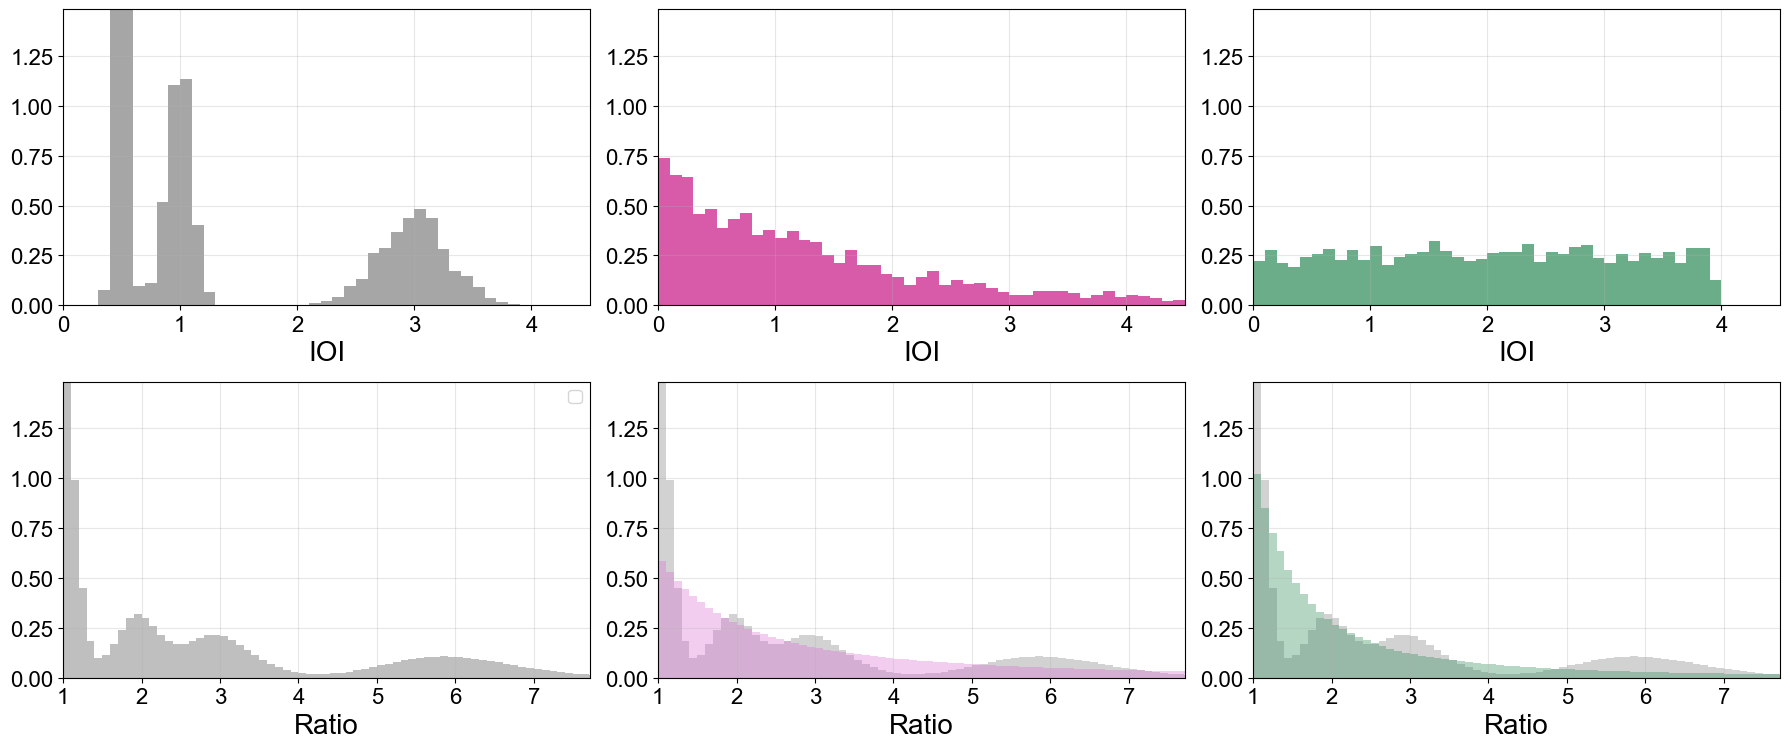

In [ ]:
# new introduction
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# font settings for publication-quality plots
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.family'] = "sans-serif"

def plot_ratio_panel_abc(
    sample_size=600,
    means=(30.2, 20.0, 10.0),
    cvs=(0.1, 0.13, 0.15),
    bins=np.arange(0, 4.6, 0.1),
    random_seed=42,
    show_kde=True
):
    rng = np.random.default_rng(random_seed)

    # --- Three Normal distributions ---
    stds = [m*c for m,c in zip(means, cvs)]
    A = rng.normal(means[0], stds[0], sample_size)
    B = rng.normal(means[1], stds[1], sample_size)
    C = rng.normal(means[2], stds[2], sample_size)

    all_values = np.concatenate([A, B, C])

    # Ratio-Function
    def ratio_pairs_unique(x, y):
        """Calculates unique ratios (without self-comparisons or duplicates)."""
        x = np.asarray(x)
        y = np.asarray(y)
        if np.array_equal(x, y):
            # same list → upper triangle without diagonal
            i_idx, j_idx = np.triu_indices(len(x), k=1)
            r = x[i_idx] / y[j_idx]
        else:
            # different lists → all combinations
            r = x[:, None] / y[None, :]
            r = r.ravel()
        r = np.maximum(r, 1 / r)
        return r

    # --- Exponential Null Model ---
    mean_all = all_values.mean()
    E = rng.exponential(scale=mean_all, size=len(all_values))

    # --- Uniform Null Model ---
    #min_all = all_values.min()
    min_all = 0.01
    max_all = all_values.max()
    U = rng.uniform(low=min_all, high=max_all, size=len(all_values))

    # --- Ratios ---
    r_AB = ratio_pairs_unique(A, B)
    r_AC = ratio_pairs_unique(A, C)
    r_BC = ratio_pairs_unique(B, C)
    r_all = ratio_pairs_unique(all_values, all_values)
    r_exp = ratio_pairs_unique(E, E)
    r_unif = ratio_pairs_unique(U, U)

    # X-Axis for lower row
    x_min = 1
    x_max = np.percentile(np.concatenate([r_AB, r_AC, r_BC, r_all]), 99)
    fig, axs = plt.subplots(2, 3, figsize=(18,8))

    # --- Top row ---

    # 1a: Combined distribution
    axs[0,0].hist(all_values, bins=bins, density=True, alpha=0.7, color="gray")
    axs[0,0].grid(alpha=0.3)
    axs[0,0].tick_params(labelsize=16)

    # 1b: Exponential
    axs[0,1].hist(E, bins=bins, density=True, alpha=0.7, color="mediumvioletred")
    axs[0,1].grid(alpha=0.3)
    axs[0,1].tick_params(labelsize=16)

    # 1c: Uniform
    axs[0,2].hist(U, bins=bins, density=True, alpha=0.7, color="seagreen")
    axs[0,2].grid(alpha=0.3)
    axs[0,2].set_xlim(0, max_all*1.1)
    axs[0,2].tick_params(labelsize=16)

    # --- Bottom row ---

    # 1d: All-vs-All Ratios
    ax = axs[1,0]
    ax.hist(r_all, bins=bins, density=True, alpha=0.5, color="gray")
    if show_kde:
        kde = gaussian_kde(r_all)
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde(x_grid), color="black", lw=2)
    ax.legend(fontsize=12)
    ax.tick_params(labelsize=16)
    ax.grid(alpha=0.3)

    # 1e: Comparison All vs. Exponential
    ax = axs[1,1]
    ax.hist(r_all, bins=bins, density=True, alpha=0.35, color="gray", label="r_all")
    ax.hist(r_exp, bins=bins, density=True, alpha=0.35, color="orchid", label="r_exp")
    if show_kde:
        kde_all = gaussian_kde(r_all)
        kde_exp = gaussian_kde(r_exp[r_exp<x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde_all(x_grid), color="black", lw=2)
        ax.plot(x_grid, kde_exp(x_grid), color="purple", lw=2, ls="--")
    #ax.legend(fontsize=12)
    ax.tick_params(labelsize=16)
    ax.grid(alpha=0.3)

    # 1f: Comparison All vs. Uniform
    ax = axs[1,2]
    ax.hist(r_all, bins=bins, density=True, alpha=0.35, color="gray", label="r_all")
    ax.hist(r_unif, bins=bins, density=True, alpha=0.35, color="seagreen", label="r_unif")
    if show_kde:
        kde_all = gaussian_kde(r_all)
        kde_unif = gaussian_kde(r_unif[r_unif<x_max])
        x_grid = np.linspace(x_min, x_max, 1000)
        ax.plot(x_grid, kde_all(x_grid), color="black", lw=2)
        ax.plot(x_grid, kde_unif(x_grid), color="green", lw=2, ls="--")
    #ax.set_title("Comparison r_all vs. r_unif", fontsize=12)
    #ax.legend(fontsize=12)
    ax.tick_params(labelsize=16)
    ax.grid(alpha=0.3)

    # --- Shared X and Y axes for lower row ---
    densities = []
    for r in [r_AB, r_AC, r_BC, r_all, r_exp]:
        kde = gaussian_kde(r[r<x_max])
        densities.append(kde(np.linspace(x_min,x_max,500)).max())
    y_max = max(densities)*1.05

    for ax in axs[0,:]:
        ax.set_xlim(0, 4.5)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("IOI", fontsize=20)
        #ax.set_ylabel("Density", fontsize=12)

    for ax in axs[1,:]:
        ax.set_xlim(1, x_max)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("Ratio",fontsize=20)
        #ax.set_ylabel("Density", fontsize=12)

    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Example call
plot_ratio_panel_abc(
    sample_size=1000,
    means=(3.0, 1.0, 0.5),
    cvs=(0.1, 0.1, 0.1),
    bins=np.arange(0, 10, 0.1),
    random_seed=42,
    show_kde=False
)

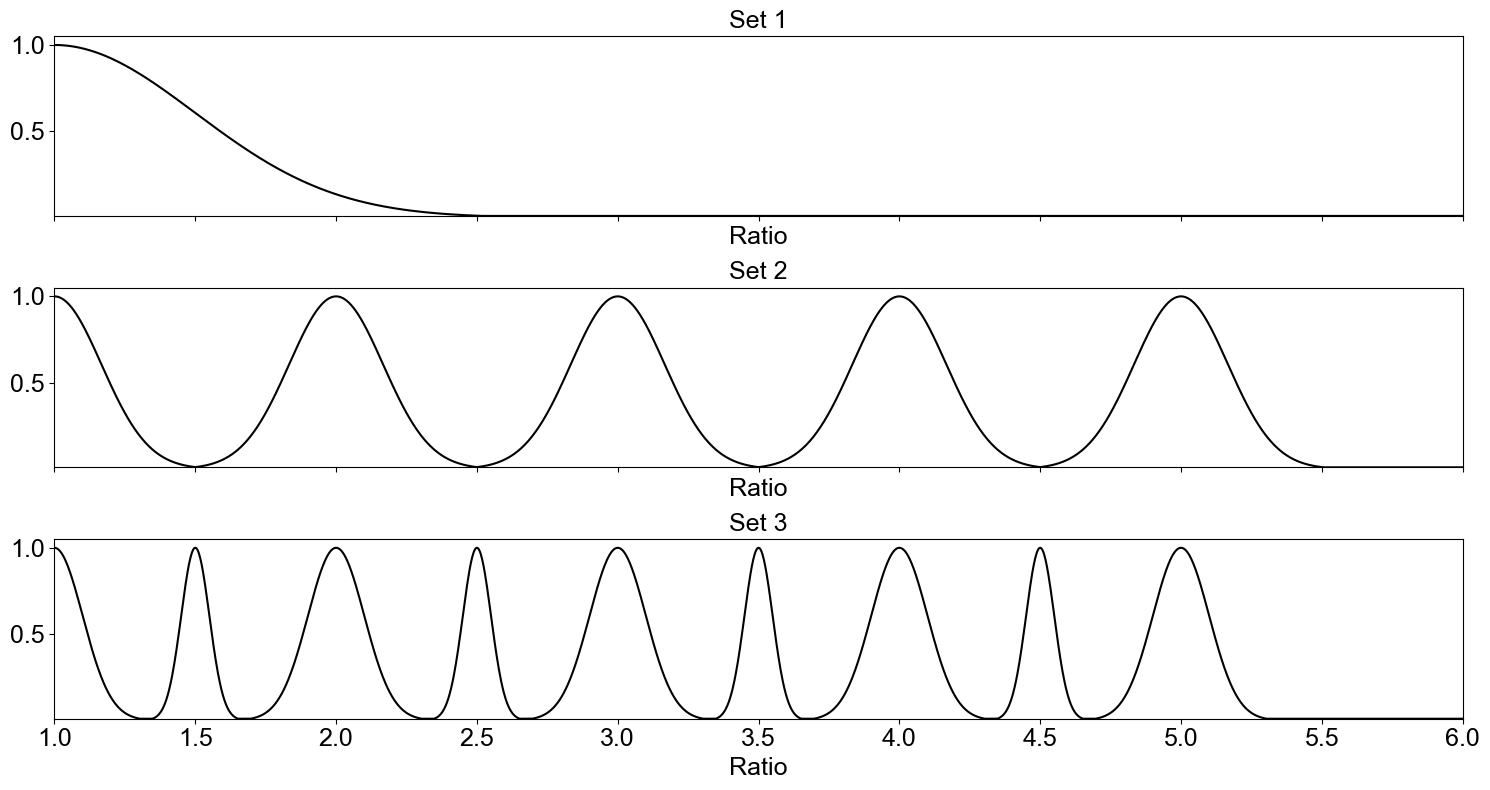

In [ ]:
# plot for param-set study
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path

# add parent directory to path for importing proximitylib
sys.path.append(str(Path("..").resolve()))  # goes one level up

import importlib
import proximitylib.proximity as prox
importlib.reload(prox)

# =============================
# Compact overlay plot
# =============================
x = np.linspace(1, 6, 2000)

fig, axs = plt.subplots(3, 1, figsize=(15,8), sharex=True, sharey=True)
for idx, params in prox.param_sets.items():
    y, _ = prox.proximity_max_freq_gaussian(x, **params)
    axs[idx-1].plot(x, y, color="black", lw=1.5)
    axs[idx-1].set_title(f"Set {idx}", fontsize=18)
    axs[idx-1].set_xlabel("Ratio", fontsize=18)
    if idx == 1:
        axs[idx-1].set_ylabel("", fontsize=10)      
    axs[idx-1].set_xlim(x.min(), x.max())
    axs[idx-1].set_ylim(params["threshold"], 1.05)    
    axs[idx-1].set_xticks([1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,6])
    axs[idx-1].tick_params(axis='x', labelsize=18)
    axs[idx-1].tick_params(axis='y', labelsize=18)

    plt.grid(False)
    plt.box(True)
            
plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

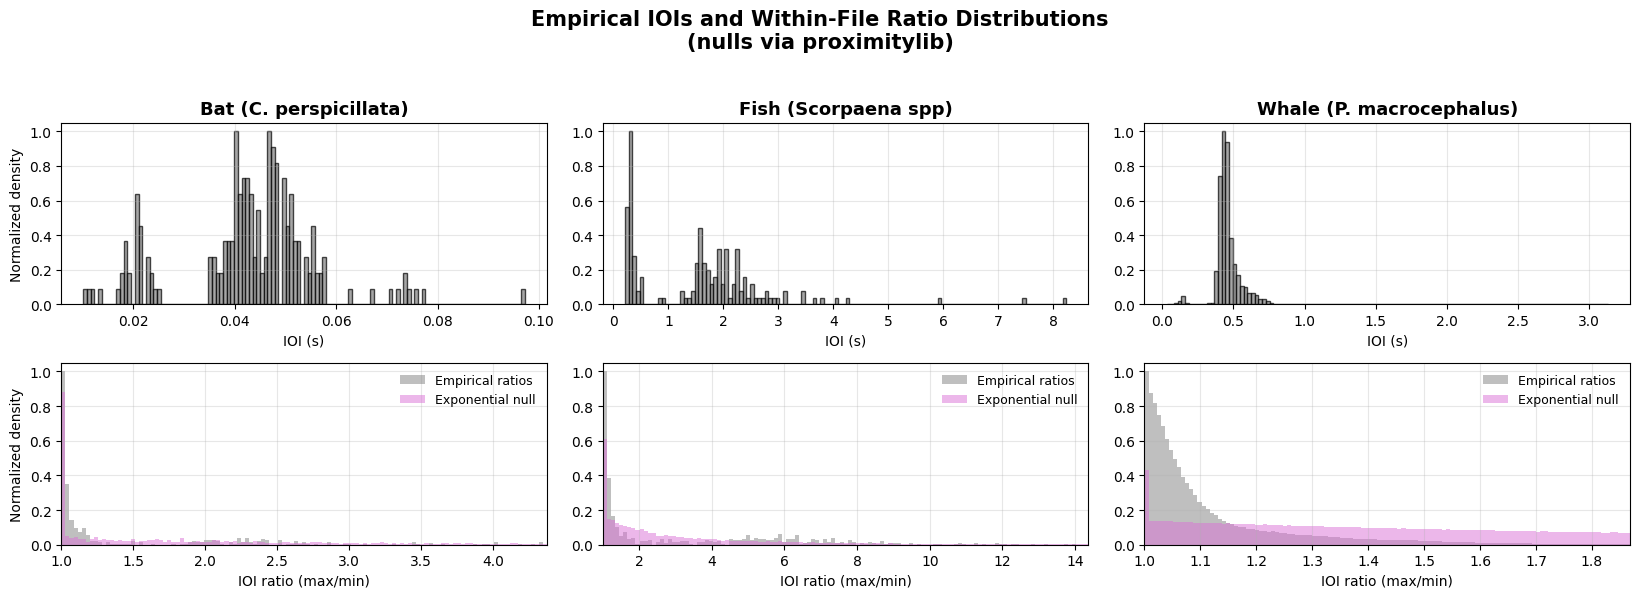

In [ ]:
# Panel plot for ratio distributions with null models

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
import sys

# add parent directory to path for importing proximitylib
sys.path.append(str(Path("..").resolve()))  # goes one level up

import importlib
import proximitylib.proximity as prox
from tabulate import tabulate
importlib.reload(prox)

def plot_ratio_panel_from_folders_with_nulls(
    folder_dict,
    bins=100,
    num_null_sequences=100,
    random_seed=42,
    max_ratio_percentile=99,
    use_proximity_weight=False,
    param_choice=1,
):
    """
    Creates a 2×N panel (empirical IOIs + ratio distributions) for multiple datasets.
    Null models are generated via prox.generate_null_sequences().
    Ratios are computed within files, and distributions normalized per dataset.

    Parameters
    ----------
    folder_dict : dict
        {"Label": "/path/to/folder", ...}
    bins : int
        Histogram bins.
    num_null_sequences : int
        Number of exponential null sequences per file.
    random_seed : int
        RNG seed.
    max_ratio_percentile : float
        Percentile cutoff for extreme ratios.
    use_proximity_weight : bool
        If True, apply proximity_max_freq_gaussian_table() as weighting to ratios.
    param_choice : int
        Parameter set for proximity weighting (if used).
    """

    rng = np.random.default_rng(random_seed)
    n = len(folder_dict)
    params = prox.param_sets[param_choice]

    fig, axs = plt.subplots(2, n, figsize=(5.5 * n, 6), sharey=False)

    for idx, (label, folder_path) in enumerate(folder_dict.items()):
        all_iois, all_ratios, all_ratios_null = [], [], []

        for file in os.listdir(folder_path):
            if not file.lower().endswith(".csv"):
                continue
            df = pd.read_csv(os.path.join(folder_path, file))
            if "IOI" not in df.columns:
                continue
            iois = df["IOI"].dropna().values
            if len(iois) < 2:
                continue

            # --- Real ratios ---
            r = (iois[:, None] / iois[None, :]).ravel()
            r = np.maximum(r, 1 / r)
            r = r[r < np.percentile(r, max_ratio_percentile)]
            all_ratios.append(r)
            all_iois.append(iois)

            # --- Null sequences über prox.generate_null_sequences() ---
            nulls = prox.generate_null_sequences(iois, num_sequences=num_null_sequences, models=("expon",), seed=random_seed)
            null_iois = nulls["expon"]

            null_ratios_list = []
            for sim_iois in null_iois:
                rr = (sim_iois[:, None] / sim_iois[None, :]).ravel()
                rr = np.maximum(rr, 1 / rr)
                rr = rr[rr < np.percentile(rr, max_ratio_percentile)]
                if use_proximity_weight:
                    # apply proximity weighting (optional, more biologically meaningful)
                    weights, _ = prox.proximity_max_freq_gaussian_table(rr, **params)
                    rr = np.repeat(rr, np.clip((weights * 10).astype(int), 1, None))  # weight ratios
                null_ratios_list.append(rr)

            all_ratios_null.append(np.concatenate(null_ratios_list))

        if not all_iois:
            print(f"⚠️ No valid IOI data in {folder_path}")
            continue

        iois_all = np.concatenate(all_iois)
        ratios_all = np.concatenate(all_ratios)
        ratios_null_all = np.concatenate(all_ratios_null)

        # histogram bins for ratios (linear scale, cutoff at max_ratio_percentile)
        x_min = 1
        x_max = np.percentile(ratios_all, max_ratio_percentile)
        bins_lin = np.linspace(x_min, x_max, bins)

        # === Upper Panel: IOI ===
        ax1 = axs[0, idx]
        h_ioi, e_ioi = np.histogram(iois_all, bins=bins, density=True)
        ax1.bar((e_ioi[:-1] + e_ioi[1:]) / 2, h_ioi / h_ioi.max(), width=np.diff(e_ioi),
                color="gray", alpha=0.7, edgecolor="black")
        ax1.set_title(label, fontsize=13, weight="bold")
        ax1.set_xlabel("IOI (s)")
        if idx == 0:
            ax1.set_ylabel("Normalized density")
        ax1.grid(alpha=0.3)

        # === Lower Panel: Ratios ===
        ax2 = axs[1, idx]
        h_emp, e_emp = np.histogram(ratios_all, bins=bins_lin, density=True)
        h_null, _ = np.histogram(ratios_null_all, bins=bins_lin, density=True)

        scale = max(h_emp.max(), h_null.max())
        h_emp /= scale
        h_null /= scale

        ax2.bar((e_emp[:-1] + e_emp[1:]) / 2, h_emp, width=np.diff(e_emp),
                alpha=0.5, color="gray", label="Empirical ratios", edgecolor="none")
        ax2.bar((e_emp[:-1] + e_emp[1:]) / 2, h_null, width=np.diff(e_emp),
                alpha=0.5, color="orchid", label="Exponential null", edgecolor="none")

        ax2.set_xlim(x_min, x_max)
        ax2.set_xlabel("IOI ratio (max/min)")
        if idx == 0:
            ax2.set_ylabel("Normalized density")
        ax2.grid(alpha=0.3)
        ax2.legend(fontsize=9, frameon=False, loc="upper right")

    fig.suptitle("Empirical IOIs and Within-File Ratio Distributions\n(nulls via proximitylib)", fontsize=15, weight="bold", y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# apply to multiple folders with null models
plot_ratio_panel_from_folders_with_nulls(
    {
        "Bat (C. perspicillata)": "../data/Bat Carollia perspicillata (C_persp)",
        "Fish (Scorpaena spp)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Kwa-Sounds Scorpaena spp",
        "Whale (P. macrocephalus)": "/Users/emilschmiedl/Desktop/Proximity-Funktion/data/Sperm whale Physeter macrocephalus (sw)",
    },
    bins=120,
    num_null_sequences=200,
    use_proximity_weight=False,  # True = proximity-weighted null ratios, False = unweighted null ratios
)


✅ Panel gespeichert unter: animals_panel.png


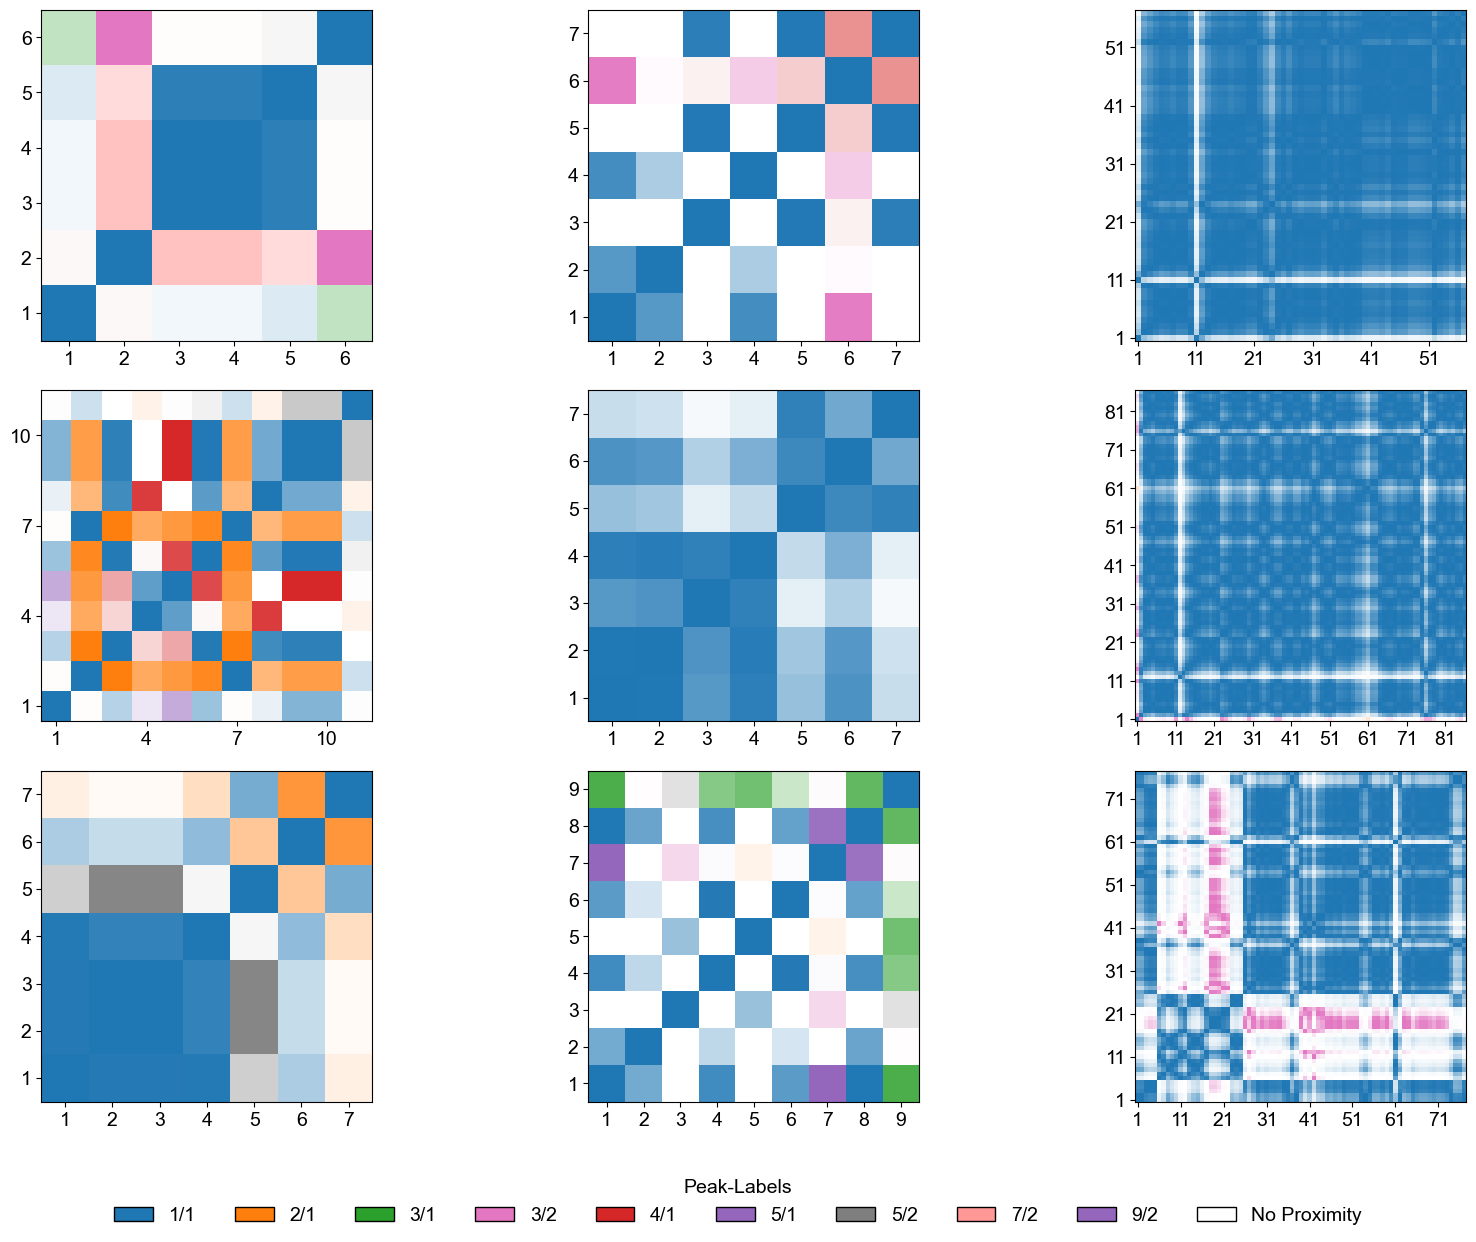

In [ ]:
# matrix panels for multiple files
from pathlib import Path
import sys

# append for parent directory to import proximitylib
sys.path.append(str(Path("..").resolve()))  # goes one level up

import importlib
import proximitylib.proximity as prox
from tabulate import tabulate
importlib.reload(prox)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from fractions import Fraction
from proximitylib.proximity import build_pairwise_proximity_df, proximity_max_freq_gaussian, param_sets
import math

# font settings for publication-quality plots
plt.rcParams['font.sans-serif'] = "Arial"
plt.rcParams['font.family'] = "sans-serif"

def panel_peak_matrices(file_paths, param_choice=0, figsize=(20, 20), draw_borders=False, save_path=None):
    """
    Panel of pairwise proximity matrices for multiple files. Each cell's color intensity reflects proximity value, and labels indicate peak types.
    Parameters
    ----------
file_paths : list of str
    List of CSV file paths, each containing an 'IOI' column.
param_choice : int
    Index of parameter set to use from proximitylib.param_sets for proximity calculation.
figsize : tuple
    Size of the overall figure (width, height).
draw_borders : bool
    If True, draw borders around each cell for better visibility.
save_path : str or None
    If provided, saves the figure to this path instead of displaying it.
    """
    n_files = len(file_paths)
    n_cols = math.ceil(n_files / 1)
    n_rows = 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=False)
    axes = axes.flatten()

    params = param_sets[param_choice]

    # Constants for color mapping
    tab10 = plt.cm.tab10.colors
    fixed_colors = {
        "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
        "1/2": tab10[5], "3/2": tab10[6], "5/2": tab10[7], "1/3": tab10[8], "2/3": tab10[9],
        "4/3": (0.5, 0.0, 0.5)
    }

    # -------------------------
    # All peak labels across all files sammeln, for consistent color mapping
    # -------------------------
    all_peak_labels = set()
    for path in file_paths:
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params)
        # explicitly convert to string and drop NaNs to avoid issues with unique()
        labels_here = pd.Series(df_pairs["peak_label"].astype(str)).dropna().unique()
        labels_here = [lab for lab in labels_here if lab != "" and lab.lower() != "nan"]
        all_peak_labels.update(labels_here)
    all_peak_labels = sorted(all_peak_labels)

    # add "No Proximity" as a baseline label if not already present
    if "No Proximity" not in all_peak_labels:
        all_peak_labels.insert(0, "No Proximity")
    
    # match each label to a color (fixed for known ratios, dynamic for others)
    label_to_color = {}
    for idx, lab in enumerate(all_peak_labels):
        if lab == "No Proximity":
            label_to_color[lab] = (1,1,1)  # white for no proximity
        elif lab in fixed_colors:
            label_to_color[lab] = fixed_colors[lab]
        else:
            color = plt.cm.tab20(idx % 20)
            label_to_color[lab] = color

    # -------------------------

    for ax, path in zip(axes, file_paths):
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        n = len(iois)

        df_pairs, ratios, prox_mat = build_pairwise_proximity_df(iois, params)
        pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
        pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

        for (i, j), val in np.ndenumerate(pivot_vals.values):
            label = pivot_labels.iloc[i, j]
            base_color = label_to_color.get(label, (0.8, 0.8, 0.8))
            alpha = val / 100 if not np.isnan(val) else 0
            color = (*base_color[:3], alpha)
            ax.add_patch(plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor="black" if draw_borders else "none", linewidth=0.4 if draw_borders else 0))
            if n <= 2 and not np.isnan(val):
                ax.text(j+0.5, i+0.5, f"{float(val.item()):.1f}", ha='center', va='center', fontsize=6, color="black")

        ax.set_xlim(0, n)
        ax.set_ylim(0, n)
        ax.set_aspect('equal')

        if len(iois) <= 10:
            ax.set_xticks(np.arange(n) + 0.5)
            ax.set_yticks(np.arange(n) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1))
            ax.set_yticklabels(np.arange(1, n+1))
        elif len(iois) <= 30:
            step = 3
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))
        else: 
            step = 10
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))

        #ax.set_title(Path(path).stem, fontsize=10, fontweight='bold')

    # Make legend with all peak labels and their colors
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=label_to_color[lab], edgecolor='black')
               for lab in all_peak_labels]
    labels = all_peak_labels  # labels are already sorted and correspond to handles
    fig.subplots_adjust(bottom=0.1, hspace=0.3)
    fig.legend(handles, labels, loc='lower center', ncol=min(len(labels), 10),
               fontsize=10, title="Peak-Labels", frameon=False)

    # Turn off axes for any unused subplots (in case n_files < n_cols*n_rows)
    for ax in axes[n_files:]:
        ax.axis('off')

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Panel saved at: {save_path}")

    plt.show()

def panel_peak_matrices_3x3(file_paths, param_choice=0, figsize=(20, 20), draw_borders=False, save_path=None):
    """
    Panel of pairwise proximity matrices for multiple files in a 3x3 layout. Each cell's color intensity reflects proximity value, and labels indicate peak types.
    Parameters
    ----------
file_paths : list of str
    List of CSV file paths, each containing an 'IOI' column.
param_choice : int
    Index of parameter set to use from proximitylib.param_sets for proximity calculation.
figsize : tuple
    Size of the overall figure (width, height).
draw_borders : bool
    If True, draw borders around each cell for better visibility.
    """
    n_files = len(file_paths)
    n_cols = math.ceil(n_files / 3)
    n_rows = 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=False)
    axes = axes.flatten()

    params = param_sets[param_choice]

    # Constants for color mapping
    tab10 = plt.cm.tab10.colors
    fixed_colors = {
        "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
        "1/2": tab10[5], "3/2": tab10[6], "5/2": tab10[7], "1/3": tab10[8], "2/3": tab10[9],
        "4/3": (0.5, 0.0, 0.5)
    }

    # -------------------------
    # Collect all peak labels across all files for consistent color mapping
    # -------------------------
    all_peak_labels = set()
    for path in file_paths:
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        df_pairs, _, _ = build_pairwise_proximity_df(iois, params)
        # explicitly convert to string and drop NaNs to avoid issues with unique()
        labels_here = pd.Series(df_pairs["peak_label"].astype(str)).dropna().unique()
        labels_here = [lab for lab in labels_here if lab != "" and lab.lower() != "nan"]
        all_peak_labels.update(labels_here)
    all_peak_labels = sorted(all_peak_labels)

    # add "No Proximity" as a baseline label if not already present
    if "No Proximity" not in all_peak_labels:
        all_peak_labels.insert(0, "No Proximity")
    
    # match each label to a color (fixed for known ratios, dynamic for others)
    label_to_color = {}
    for idx, lab in enumerate(all_peak_labels):
        if lab == "No Proximity":
            label_to_color[lab] = (1,1,1)  # white for no proximity
        elif lab in fixed_colors:
            label_to_color[lab] = fixed_colors[lab]
        else:
            color = plt.cm.tab20(idx % 20)
            label_to_color[lab] = color

    # -------------------------

    for ax, path in zip(axes, file_paths):
        df = pd.read_csv(path)
        iois = df["IOI"].dropna().values
        n = len(iois)

        df_pairs, ratios, prox_mat = build_pairwise_proximity_df(iois, params)
        pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
        pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

        for (i, j), val in np.ndenumerate(pivot_vals.values):
            label = pivot_labels.iloc[i, j]
            base_color = label_to_color.get(label, (0.8, 0.8, 0.8))
            alpha = val / 100 if not np.isnan(val) else 0
            color = (*base_color[:3], alpha)
            ax.add_patch(plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor="black" if draw_borders else "none", linewidth=0.4 if draw_borders else 0))
            if n <= 2 and not np.isnan(val):
                ax.text(j+0.5, i+0.5, f"{float(val.item()):.1f}", ha='center', va='center', fontsize=6, color="black")

        ax.set_xlim(0, n)
        ax.set_ylim(0, n)
        ax.set_aspect('equal')

        if len(iois) <= 10:
            ax.set_xticks(np.arange(n) + 0.5)
            ax.set_yticks(np.arange(n) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1))
            ax.set_yticklabels(np.arange(1, n+1))
        elif len(iois) <= 30:
            step = 3
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))
        else: 
            step = 10
            ax.set_xticks(np.arange(0, n, step) + 0.5)
            ax.set_yticks(np.arange(0, n, step) + 0.5)
            ax.set_xticklabels(np.arange(1, n+1, step))
            ax.set_yticklabels(np.arange(1, n+1, step))

        ax.tick_params(labelsize=14)

       #ax.set_title(Path(path).stem, fontsize=10, fontweight='bold')

    # Make legend with all peak labels and their colors
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=label_to_color[lab], edgecolor='black')
               for lab in all_peak_labels]
    labels = all_peak_labels  # labels are already sorted and correspond to handles
    fig.subplots_adjust(bottom=0.1, hspace=0.15)
    fig.legend(handles, labels, loc='lower center', ncol=min(len(labels), 10),
               fontsize=14, title="Peak-Labels", title_fontsize=14, frameon=False)

    # Turn off axes for any unused subplots (in case n_files < n_cols*n_rows)
    for ax in axes[n_files:]:
        ax.axis('off')

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Panel saved at: {save_path}")

    plt.show()

files1 = [
    "../data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-1-2_jitter-0050/heterochrony-1-2_jitter-0050_04.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_jitter-0001/isochrony_jitter-0001_04.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/random_exponential/random_exponential_03.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_drift/isochrony_drift.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/jitter_middle-0050/jitter_middle-0050_02.csv",
]

files2 = [
    "../data/theoretical_sequences/baseIOI-0.50/20beats/heterochrony-2-3_jitter-0050/heterochrony-2-3_jitter-0050_06.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/isochrony_jitter-0050/isochrony_jitter-0050_03.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/random_uniform/random_uniform_05.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/accelerando/accelerando.csv",
    "../data/theoretical_sequences/baseIOI-0.50/20beats/tempo_shift_onlyioi-jitter-0050/tempo_shift_onlyioi-jitter-0050_06.csv",
]

animals = [
    "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p4_b4.csv",
    "../data/Kwa-Sounds (Scorpaena spp.)/KWA2-C.csv",
    "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_02.xls.csv",
    "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p4_b9.csv",
    "../data/Kwa-Sounds (Scorpaena spp.)/KWA6.csv",
    "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_32.xls.csv",
    "../data/Seba's short-tailed bat (Carollia perspicillata)/C_persp_IC_p2_b7.csv",
    "../data/Kwa-Sounds (Scorpaena spp.)/KWA10.csv",
    "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_51.xls.csv",
]

panel_peak_matrices(files1, param_choice=3, figsize=(18, 4), draw_borders=True)
panel_peak_matrices(files2, param_choice=3, figsize=(18, 4), draw_borders=True)
panel_peak_matrices_3x3(animals, param_choice=3, figsize=(20, 14), draw_borders=False)

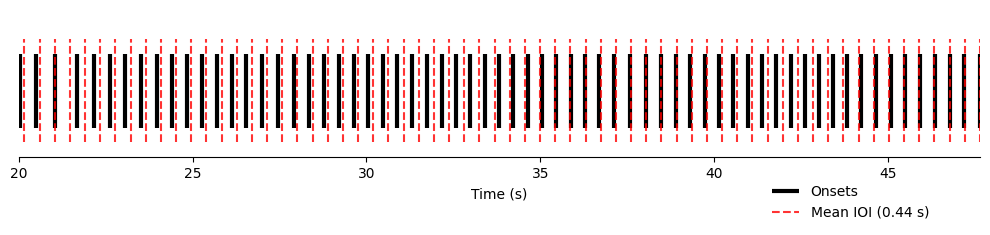

In [ ]:
# Visualisation of Onsets and Perfect Beat for a single file

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) Reading the data
# =========================

path = "../data/Sperm whale (Physeter macrocephalus)/sw114a002_coda_53.xls.csv"
filename = path.split("/")[-1].replace(".xls.csv", "")
df = pd.read_csv(path)
onsets = df["onset"].values
iois = df["IOI"].dropna().values

# =========================
# 2) Mean IOI ("perfect Beat")
# =========================
mean_ioi = np.mean(iois)

t_start = onsets.min()
t_end = onsets.max()

perfect_beats = np.arange(t_start, t_end + mean_ioi, mean_ioi)

# =========================
# 3) Plot
# =========================
fig, ax = plt.subplots(figsize=(10, 2.5))

# reale Onsets (black)
ax.vlines(
    onsets,
    ymin=0.20,
    ymax=0.70,
    color="black",
    linewidth=3,
    label="Onsets"
)

# perfect Beat (red)
ax.vlines(
    perfect_beats,
    ymin=0.10,
    ymax=0.80,
    color="red",
    linewidth=1.5,
    alpha=0.8,
    linestyle="--",
    label=f"Mean IOI ({mean_ioi:.2f} s)"
)

# =========================
# 4) Paper-Style
# =========================
ax.set_ylim(0, 1)
ax.set_xlim(20, t_end)
ax.set_xlabel("Time (s)")
ax.set_yticks([])

for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(0.96, -0.1)
)

plt.tight_layout()
plt.show()